In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchvision import transforms
from PIL import Image
import pickle
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F
import pandas as pd

In [2]:
# load_any_dataset.py を使うことで、クラス名が違うpkl（広島データ・島根データ）でも
# 同じように読み込めるようにする。
import sys
sys.path.append(r"C:\Users\hirok\OneDrive\Desktop\CrZ\simane\MakeDataSet")  # load_any_dataset.pyがあるフォルダ（要調整）
from load_any_dataset import load_dataset, dem_dataset

#path = "processed_dem_dataset_ver2.pkl"
#path = "D:\\KU\\processed_dem_dataset_ver3.pkl"
path = "C:\\Users\\hirok\\OneDrive\\Desktop\\CrZ\\simane\\MakeDataSet\\hiroshima_sam.pkl"
dataset = load_dataset(path)
print(len(dataset.No))
print(dataset.DEM[0].shape)

38148
(128, 128)


In [3]:
dataset2 = dem_dataset()
#images2 = []
for i in range(len(dataset.No)):
    if np.max(np.array(dataset.Mask[i])) >= 1:
        dataset2.DEM.append(dataset.DEM[i])
        dataset2.Mask.append(dataset.Mask[i])
        dataset2.No.append(dataset.No[i])
        dataset2.GeoInfo.append(dataset.GeoInfo[i])
        dataset2.EPSG.append(dataset.EPSG[i])
        dataset2.Max_H.append(dataset.Max_H[i])
        dataset2.Min_H.append(dataset.Min_H[i])
        #images2.append(images[i])
print(len(dataset2.DEM))
print(len(dataset2.Mask))
#print(len(images2))

14816
14816


In [4]:
#del images
del dataset

In [5]:
from scipy.ndimage import gaussian_filter
for i in range(len(dataset2.No)):
    dataset2.Mask[i] = np.array(dataset2.Mask[i])
    dataset2.Mask[i] = dataset2.Mask[i].astype(np.uint8) * 255
    dataset2.Mask[i] = gaussian_filter(dataset2.Mask[i], sigma=1)
    dataset2.Mask[i] = (dataset2.Mask[i] > 0).astype(np.uint8)

In [6]:
# データをnumpy配列に
dataset2.DEM = np.array(dataset2.DEM)
dataset2.Mask = np.array(dataset2.Mask)

# データの形状を合わせる
dataset2.DEM = np.expand_dims(dataset2.DEM, axis=1)  # [batch_size, 1, 150, 225]
dataset2.Mask = np.expand_dims(dataset2.Mask, axis=1)  # [batch_size, 1, 150, 225]

# NumPy 配列から PyTorch Tensor に変換
dataset2.DEM = torch.tensor(dataset2.DEM, dtype=torch.float32)
dataset2.Mask = torch.tensor(dataset2.Mask, dtype=torch.float32)


# 確認
print(dataset2.DEM.shape)  # torch.Size([batch_size, 1, 128, 128])
print(dataset2.Mask.shape) # torch.Size([batch_size, 1, 128, 128])

# 訓練データとテストデータに分割(hold out)
X_train, X_test, y_train, y_test, No_train, No_test, xh_train, xh_test, nh_train, nh_test = train_test_split(dataset2.DEM, dataset2.Mask, dataset2.No, dataset2.Max_H, dataset2.Min_H, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test, No_train, No_test, xh_train, xh_test, nh_train, nh_test = train_test_split(dataset.DEM, dataset.Mask, dataset.No, dataset.Max_H, dataset.Min_H, test_size=0.2)


# 確認
print("After reshape - X_train shape:", X_train.shape)
print("After reshape - y_train shape:", y_train.shape)

torch.Size([14816, 1, 128, 128])
torch.Size([14816, 1, 128, 128])
After reshape - X_train shape: torch.Size([11852, 1, 128, 128])
After reshape - y_train shape: torch.Size([11852, 1, 128, 128])


In [7]:
import torch
import torchvision.transforms.functional as TF
import random

class JointTransform:
    def __init__(self,
                 rotation_deg=10,
                 translate=0.1,
                 scale_range=(0.9, 1.1),
                 hflip=True,
                 vflip=True):
        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip
        self.vflip = vflip

    def __call__(self, image, mask):
        # --- ランダム角度・拡大率・平行移動のパラメータを生成 ---
        angle = random.uniform(-self.rotation_deg, self.rotation_deg)
        scale = random.uniform(self.scale_range[0], self.scale_range[1])
        max_dx = self.translate * image.shape[2]
        max_dy = self.translate * image.shape[1]
        translations = (random.uniform(-max_dx, max_dx),
                        random.uniform(-max_dy, max_dy))
        
        # --- ランダム左右反転 ---
        if self.hflip and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # --- ランダム上下反転 ---
        if self.vflip and random.random() < 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # --- アフィン変換を画像とマスクに同時適用 ---
        image = TF.affine(image, angle=angle, translate=translations,
                          scale=scale, shear=0, interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.affine(mask, angle=angle, translate=translations,
                         scale=scale, shear=0, interpolation=TF.InterpolationMode.NEAREST)

        return image, mask


In [8]:
# PyTorch Dataset クラスの定義
class ImageDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        #image = torch.tensor(self.images[idx], dtype=torch.float32)  # 画像をTensorに変換
        #mask = torch.tensor(self.masks[idx], dtype=torch.float32)  # マスクもTensorに変換
        image = torch.as_tensor(self.images[idx], dtype=torch.float32)  # GPU に転送する場合も対応
        mask = torch.as_tensor(self.masks[idx], dtype=torch.float32)
        
        if self.transform:
            image, mask = self.transform(image, mask)


        return image, mask
    
# オーグメンテーションの定義
joint_transform = JointTransform(
    rotation_deg=15,
    translate=0.1,
    scale_range=(0.8, 1.2),
    hflip=True,
    vflip=True
)

# データセット作成
train_dataset = ImageDataset(X_train, y_train)
test_dataset = ImageDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# データローダーの動作確認
for i, (inputs, labels) in enumerate(train_loader):
    print(f"Batch {i+1}: Input shape: {inputs.shape}, Label shape: {labels.shape}")

Batch 1: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 2: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 3: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 4: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 5: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 6: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 7: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 8: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 9: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 10: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])
Batch 11: Input shape: torch.Size([32, 

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.8, beta=0.2, gamma=0.75, smooth=1e-6):
        """
        alpha: False negative penalty
        beta: False positive penalty
        gamma: Focal parameter
        smooth: Avoid division by zero
        """
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, preds, targets):
        """
        preds: Predicted probabilities (N, C, H, W) or (N, 1, H, W)
        targets: Ground truth labels (N, C, H, W) or (N, 1, H, W)
        """
        #preds = torch.sigmoid(preds)  # 確率に変換
        preds = torch.sigmoid(preds.clamp(-10, 10))

        # Flatten tensors
        preds = preds.view(preds.size(0), -1)        
        targets = targets.view(targets.size(0), -1)

        TP = (preds * targets).sum(1)
        FP = ((1 - targets) * preds).sum(1)
        FN = (targets * (1 - preds)).sum(1)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
         # 数値安定化: tverskyの範囲を [0,1] に保つ
        tversky = torch.clamp(tversky, min=self.smooth, max=1.0)
        focal_tversky = torch.pow((1 - tversky), self.gamma)

        return focal_tversky.mean()

criterion = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)
def calc_loss(pred, target):
    loss = criterion(pred, target)
    return loss

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

         # エンコーダ（ダウンサンプリングパス）
        self.enc1 = self.conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        # ボトルネック
        self.bottleneck = self.conv_block(512, 1024)
        self.dropout = nn.Dropout(0.5) # Add dropout with rate 0.5

        # デコーダ（アップサンプリングパス）
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)  # concatenation of enc4 and up4
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)  # concatenation of enc3 and up3
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)  # concatenation of enc2 and up2
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)  # concatenation of enc1 and up1

        # 出力層
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
        return block

    def forward(self, x):
        # エンコーダ
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))
        enc4 = self.dropout2(enc4)

        # ボトルネック
        bottleneck = self.bottleneck(self.pool4(enc4))
        bottleneck = self.dropout(bottleneck)  # Apply dropout

        # デコーダ
        dec4 = self.dec4(torch.cat([self.up4(bottleneck), enc4], 1))
        dec4 = self.dropout2(dec4)
        dec3 = self.dec3(torch.cat([self.up3(dec4), enc3], 1))
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc2], 1))
        dec1 = self.dec1(torch.cat([self.up1(dec2), enc1], 1))

        return self.out_conv(dec1)

# サンプルの使用例
if __name__ == "__main__":
    model = UNet(in_channels=1, out_channels=1)
    print(model)
    x = torch.randn(1, 1, 128, 128) # Single grayscale image of size 128x128
    output = model(x)
    print(output.shape)


# モデル、損失関数、オプティマイザをインスタンス化
model = UNet()

# 損失関数とオプティマイザ
#criterion = nn.BCEWithLogitsLoss()
loss_fn = calc_loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# GPUがサポートされている場合
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)

UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

In [11]:
print(device)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

cuda
True
1


In [12]:
losses = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
test_f1_scores = []
best_f1_score = 0.0

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# 保存するエポック間隔を設定（例えば10エポックごと）
save_interval = 10
save_path = "model_checkpoint.pth"


# **学習の途中から再開**
if os.path.exists(save_path):
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1  # 次のエポックから開始
    print(f"Checkpoint loaded! Resuming from epoch {start_epoch}")

# 初始化存储每个 epoch 的指标
#losses = []
#accuracies = []
#precisions = []
#recalls = []
#f1_scores = []

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    # 用于存储每个 epoch 中所有批次的预测值和真实值
    all_preds = []
    all_targets = []
    

    # 使用 tqdm 包装训练数据加载器以显示进度条
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for images, masks in train_loader_tqdm:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        #loss = criterion(outputs, masks)
        loss = loss_fn(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 予測値を計算して収集する
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.append(preds.cpu().numpy().flatten())
        all_targets.append(masks.cpu().numpy().flatten())

        # 计算批次的准确率
        correct_preds += (preds == masks).sum().item()
        total_preds += masks.numel()

        # 更新 tqdm 的描述信息
        train_loader_tqdm.set_postfix(loss=loss.item())

    # 计算每个 epoch 的平均损失和准确率
    avg_loss = running_loss / len(train_loader)
    avg_accuracy = correct_preds / total_preds

    # 将所有批次的数据拼接起来
    all_preds = np.concatenate(all_preds).astype(int)
    all_targets = np.concatenate(all_targets).astype(int)

    # 计算 Precision、Recall 和 F1 分数
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)

    # 存储指标
    losses.append(avg_loss)
    accuracies.append(avg_accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    #print(f"loss : {avg_loss}, accuracie : {avg_accuracy}, pricision : {precision}, recall : {recall}, f1 : {f1}")
    
    # テストデータで評価
    model.eval()
    test_preds = []
    test_targets = []
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            test_preds.append(preds.cpu().numpy().flatten())
            test_targets.append(masks.cpu().numpy().flatten())

    test_preds = np.concatenate(test_preds).astype(int)
    test_targets = np.concatenate(test_targets).astype(int)
    test_f1 = f1_score(test_targets, test_preds, zero_division=0)
    test_f1_scores.append(test_f1)
    print(f"test f1 : {test_f1}")

    # ベストモデルの保存
    if test_f1 > best_f1_score:
        best_f1_score = test_f1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'best_f1_score': best_f1_score
        }, "best_model.pth")
        print(f"Best model saved at epoch {epoch+1} with F1-score: {test_f1:.4f}")

    
    # 学習ループ内（エポックごと）
    if (epoch + 1) % save_interval == 0:  # 10エポックごとに保存
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }
        torch.save(checkpoint, save_path)
        # 创建 DataFrame
        df = pd.DataFrame({
            "Epoch": list(range(1, len(losses) + 1)),
            "Loss": losses,
            "Accuracy": accuracies,
            "Precision": precisions,
            "Recall": recalls,
            "F1-score": f1_scores,
            "Test-F1-score" : test_f1_scores
        })
        # 保存为 CSV 文件
        df.to_csv("losses.csv", index=False, encoding="utf-8") 
        print(f"Checkpoint saved at epoch {epoch + 1}")
        

    # 打印每个 epoch 的指标
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}, "
          f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 27.10it/s]


test f1 : 0.4331848001765149
Best model saved at epoch 1 with F1-score: 0.4332
Epoch [1/100], Loss: 0.7276, Accuracy: 0.6979, Precision: 0.2227, Recall: 0.8995, F1-score: 0.3571


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 26.13it/s]


test f1 : 0.4716577150984049
Best model saved at epoch 2 with F1-score: 0.4717
Epoch [2/100], Loss: 0.6842, Accuracy: 0.7708, Precision: 0.2727, Recall: 0.8743, F1-score: 0.4157


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 27.32it/s]


...

test f1 : 0.559788028863438
Epoch [98/100], Loss: 0.3575, Accuracy: 0.9406, Precision: 0.6362, Recall: 0.8483, F1-score: 0.7271


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 26.84it/s]


test f1 : 0.537585540972664
Epoch [99/100], Loss: 0.3542, Accuracy: 0.9418, Precision: 0.6425, Recall: 0.8485, F1-score: 0.7313


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 26.35it/s]


test f1 : 0.5609786356738167
Checkpoint saved at epoch 100
Epoch [100/100], Loss: 0.3493, Accuracy: 0.9425, Precision: 0.6448, Recall: 0.8532, F1-score: 0.7345


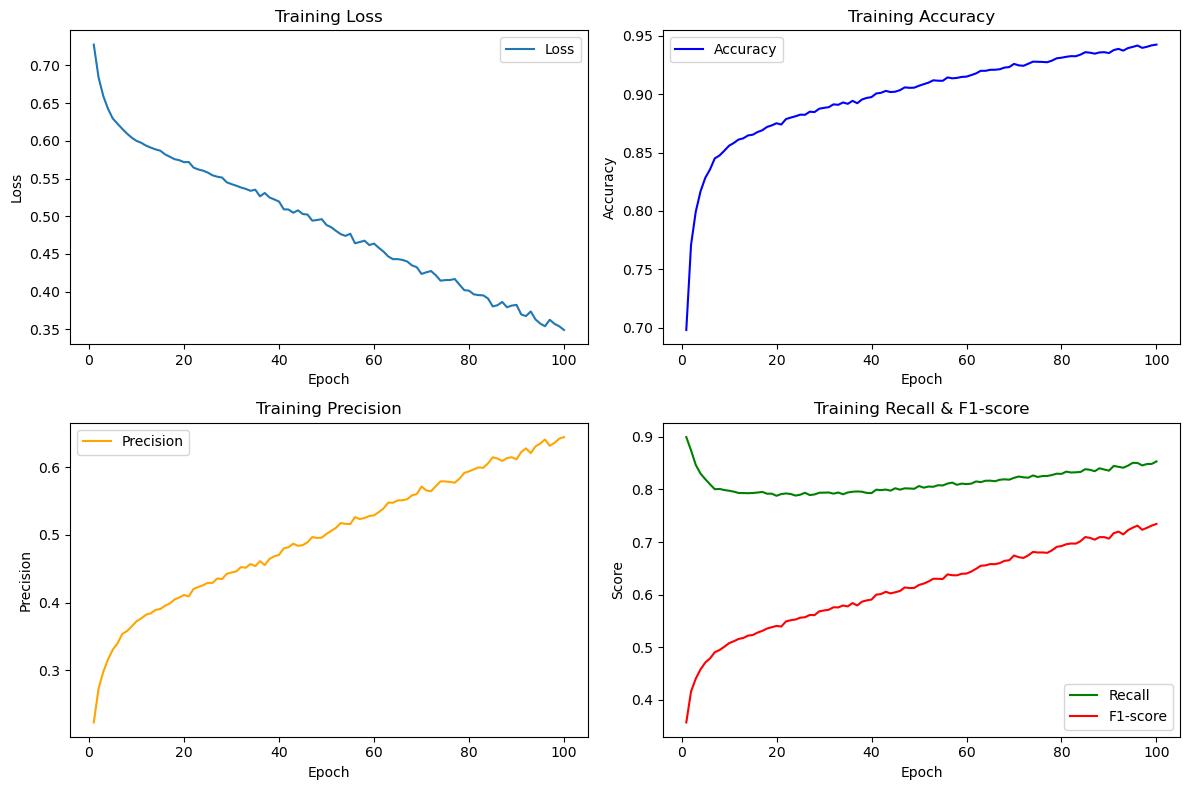

In [22]:
# 绘制曲线
plt.figure(figsize=(12, 8))

# 绘制 Loss 曲线
plt.subplot(2, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(2, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label="Accuracy", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# 绘制 Precision 曲线
plt.subplot(2, 2, 3)
plt.plot(range(1, num_epochs + 1), precisions, label="Precision", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")
plt.legend()

# 绘制 Recall 和 F1-score 曲线
plt.subplot(2, 2, 4)
plt.plot(range(1, num_epochs + 1), recalls, label="Recall", color="green")
plt.plot(range(1, num_epochs + 1), f1_scores, label="F1-score", color="red")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

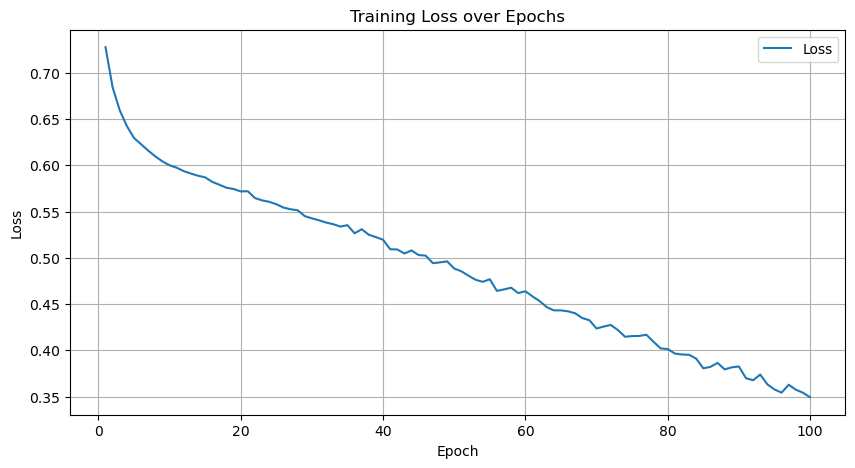

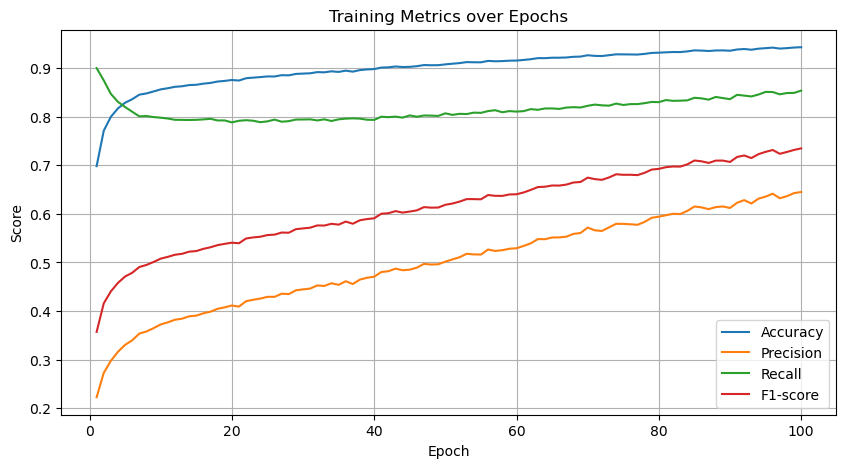

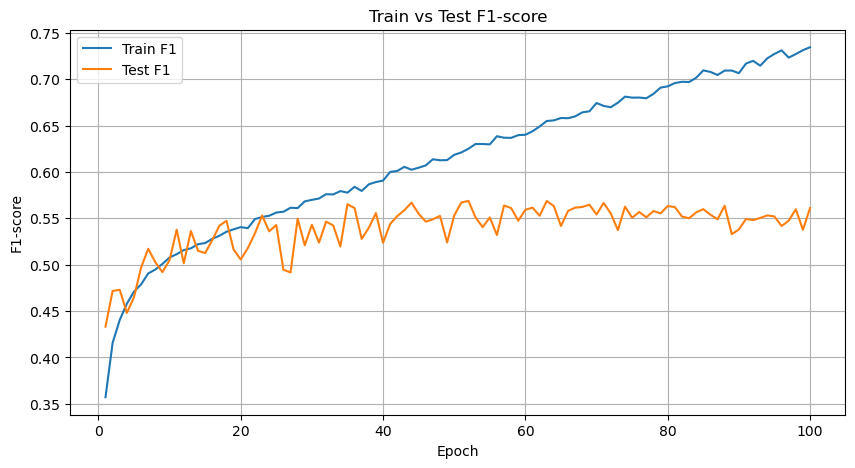

In [23]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses) + 1))

# 1. 学習曲線（Loss）
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 2. 評価指標の推移
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, precisions, label='Precision')
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, f1_scores, label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train vs Test F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, label='Train F1')
plt.plot(epochs, test_f1_scores, label='Test F1')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('Train vs Test F1-score')
plt.legend()
plt.grid(True)
plt.show()

Checkpoint loaded!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:05<00:00, 18.36it/s]


Recall: 0.6936
Precision: 0.4821
F1-score: 0.5688
[[40655605  3375941]
 [ 1388186  3142444]]


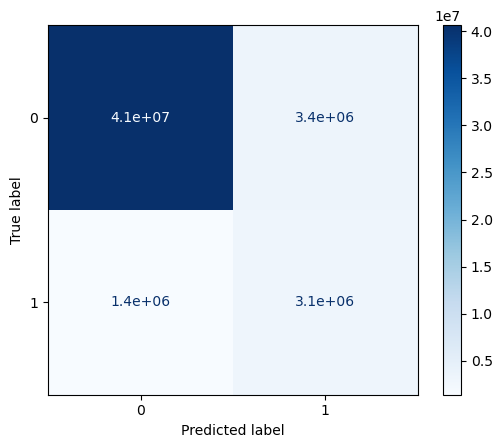

In [14]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **学習の途中から再開**
save_path = "best_model.pth"
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded!")

# 假设模型已经加载并设置为评估模式
model.eval()

# 存储路径
#model_save_path = "buf/kifuku_newdataver3_model.pth"
#torch.save(model.state_dict(), model_save_path)
#print(f"Model saved to {model_save_path}")

# 在测试数据上进行评估
all_preds = []
all_targets = []


#個所数評価用
all_preds_imgs=[]
all_targets_imgs=[]


# 遍历测试集
with torch.no_grad():  # 禁用梯度计算
    for images, masks in tqdm(test_loader, desc="Evaluating"):
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        outputs = model(images)

        # 将输出值转换为二值预测（0 或 1）
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        all_preds.append(preds.cpu())  # 将数据从 GPU 转移到 CPU
        all_targets.append(masks.cpu())  # 将目标从 GPU 转移到 CPU
        #個所数評価よう
        all_preds_imgs.append(preds.cpu().numpy())
        all_targets_imgs.append(masks.cpu().numpy())



# 拼接所有批次的预测和标签
all_preds = torch.cat(all_preds).numpy().flatten()  # 转换为 NumPy 数组并展平
all_targets = torch.cat(all_targets).numpy().flatten()  # 转换为 NumPy 数组并展平

# 确保预测和标签为整数类型
all_preds = all_preds.astype(int)
all_targets = all_targets.astype(int)


# 计算 Recall、Precision 和 F1-score
recall = recall_score(all_targets, all_preds, zero_division=0)
precision = precision_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

# 打印评估指标
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

Generating Predictions: 100%|██████████████████████████████████████████████████████████| 93/93 [00:03<00:00, 26.93it/s]


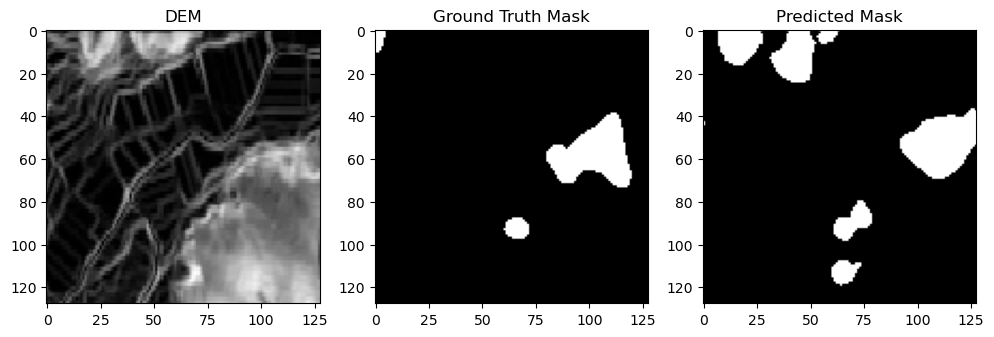

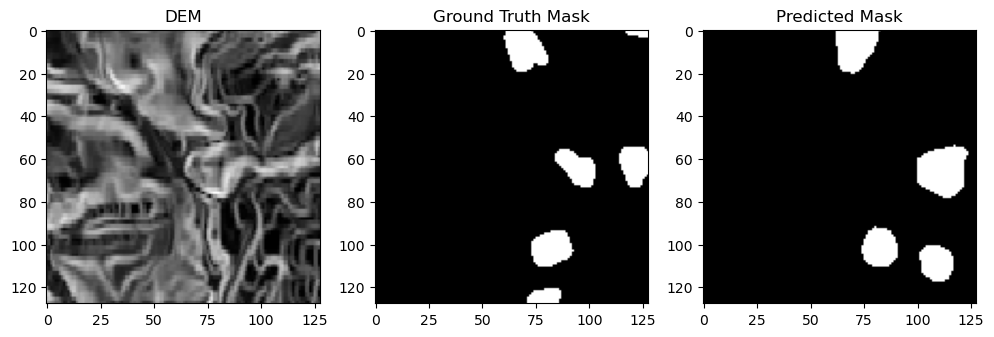

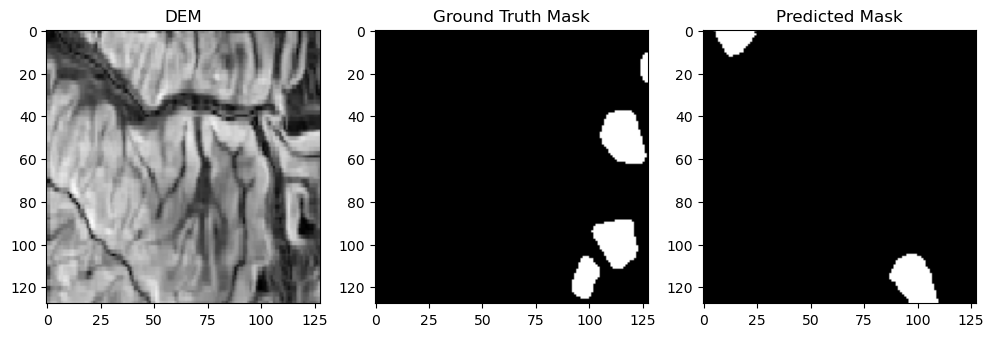

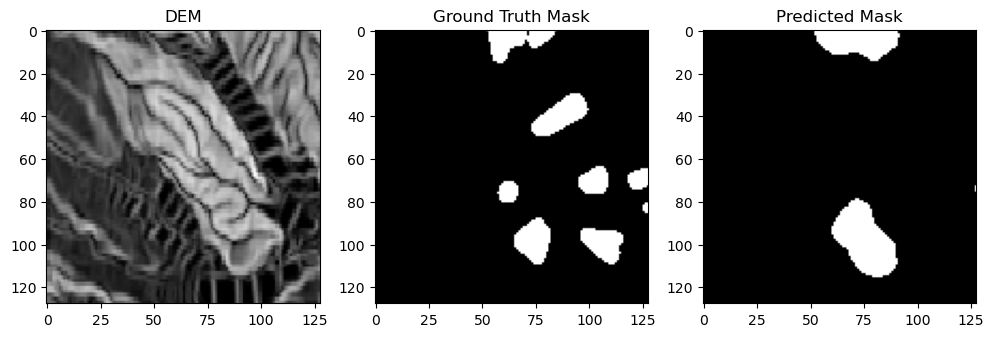

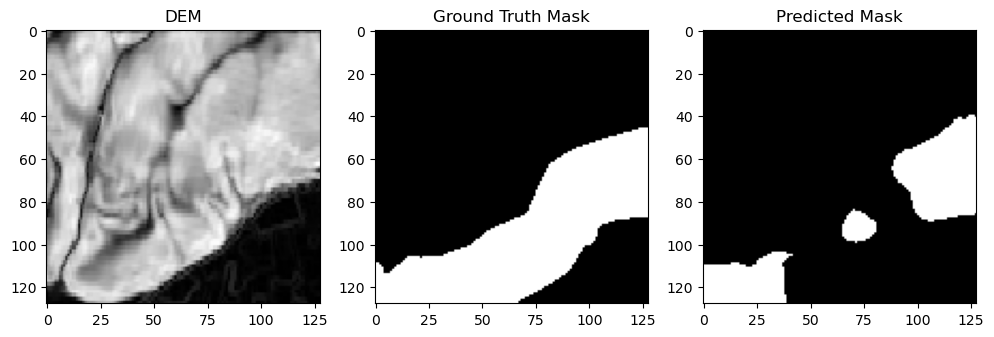

予測結果の画像枚数: 2964


In [15]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设置模型为评估模式
model.eval()

# 用于存储测试集的预测结果
predictions = []
inputs = []
ground_truths = []

# 在测试集上生成预测结果
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Generating Predictions"):
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        predictions.append(preds.cpu())
        inputs.append(images.cpu())
        ground_truths.append(masks.cpu())

# 将所有批次结果拼接
predictions = torch.cat(predictions).numpy()
inputs = torch.cat(inputs).numpy()
ground_truths = torch.cat(ground_truths).numpy()

# 显示和保存预测结果
n_display = 5  # 显示的图片数量
for i in range(n_display):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1,3,1)
    plt.title('DEM')
    plt.imshow(inputs[i][0], cmap='gray')

    # Ground Truth Mask
    plt.subplot(1, 3, 2)
    plt.title('Ground Truth Mask')
    plt.imshow(ground_truths[i][0], cmap='gray')  # 真值掩码假设为单通道

    # Predicted Mask
    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(predictions[i][0], cmap='gray')  # 预测掩码假设为单通道

    plt.show()

print(f"予測結果の画像枚数: {len(predictions)}")

## 島根県データセットでの汎化性能評価

広島データで学習したモデルを、別プレフェクチャである島根県のデータ（`load_any_dataset`経由で読み込み）で評価する。
学習データと異なり、警戒区域を含まない背景タイルも除外せず全て評価対象に含めている。

In [16]:
# ============================================================
# 1. 島根データの読み込み
# ============================================================
shimane_path = "C:\\Users\\hirok\\OneDrive\\Desktop\\CrZ\\simane\\MakeDataSet\\shimane_sam.pkl"  # 実際のファイルパスに変更してください
shimane_ds = load_dataset(shimane_path)
print(f"島根データ タイル数: {len(shimane_ds.No)}")
print(f"DEM[0] shape: {np.array(shimane_ds.DEM[0]).shape}")

# 【正規化についての注意】
# normalize_dem.py で (DEM - Min_H) / scale による正規化を既に適用したpklを
# 読み込む前提。もしまだ正規化していないpklを使う場合は、ここで学習データと
# 同じ scale ・同じ方式で正規化してから次のセルに進むこと。
# （学習側セル6の古い正規化 (X - nh) / (xh - nh) とは別方式なので、
#   学習データ側もnormalize_dem.pyで作り直した場合のみ整合する）

島根データ タイル数: 24569
DEM[0] shape: (128, 128)


In [17]:
#テストデータも急傾斜をふくむやつのみ
shimane_OnlyDanger_ds = dem_dataset()
#images2 = []
for i in range(len(shimane_ds.No)):
    if np.max(np.array(shimane_ds.Mask[i])) >= 1:
        shimane_OnlyDanger_ds.DEM.append(shimane_ds.DEM[i])
        shimane_OnlyDanger_ds.Mask.append(shimane_ds.Mask[i])
        shimane_OnlyDanger_ds.No.append(shimane_ds.No[i])
        shimane_OnlyDanger_ds.GeoInfo.append(shimane_ds.GeoInfo[i])
        shimane_OnlyDanger_ds.EPSG.append(shimane_ds.EPSG[i])
        shimane_OnlyDanger_ds.Max_H.append(shimane_ds.Max_H[i])
        shimane_OnlyDanger_ds.Min_H.append(shimane_ds.Min_H[i])
        #images2.append(images[i])
print(len(shimane_OnlyDanger_ds.DEM))
print(len(shimane_OnlyDanger_ds.Mask))
#print(len(images2))

9679
9679


In [18]:
# ============================================================
# 2. マスクにガウシアンフィルターを適用（学習時と同じ前処理）し、Tensor化
#    学習データと違い、警戒区域を含まないタイルも除外せず全て使う
# ============================================================
from scipy.ndimage import gaussian_filter

shimane_dem_list = []
shimane_mask_list = []
for i in range(len(shimane_OnlyDanger_ds.No)):
    dem_i = np.array(shimane_OnlyDanger_ds.DEM[i])
    mask_i = np.array(shimane_OnlyDanger_ds.Mask[i]).astype(np.uint8) * 255
    mask_i = gaussian_filter(mask_i, sigma=1)
    mask_i = (mask_i > 0).astype(np.uint8)
    shimane_dem_list.append(dem_i)
    shimane_mask_list.append(mask_i)

shimane_dem_arr = np.array(shimane_dem_list)
shimane_mask_arr = np.array(shimane_mask_list)

shimane_dem_arr = np.expand_dims(shimane_dem_arr, axis=1)   # [N, 1, 128, 128]
shimane_mask_arr = np.expand_dims(shimane_mask_arr, axis=1)  # [N, 1, 128, 128]

X_shimane = torch.tensor(shimane_dem_arr, dtype=torch.float32)
y_shimane = torch.tensor(shimane_mask_arr, dtype=torch.float32)

print("X_shimane shape:", X_shimane.shape)
print("y_shimane shape:", y_shimane.shape)

X_shimane shape: torch.Size([9679, 1, 128, 128])
y_shimane shape: torch.Size([9679, 1, 128, 128])


In [19]:
# ============================================================
# 3. DataLoader作成
# ============================================================
shimane_dataset = ImageDataset(X_shimane, y_shimane)
shimane_loader = DataLoader(shimane_dataset, batch_size=32, shuffle=False)

for i, (inputs, labels) in enumerate(shimane_loader):
    print(f"Batch {i+1}: Input shape: {inputs.shape}, Label shape: {labels.shape}")
    break

Batch 1: Input shape: torch.Size([32, 1, 128, 128]), Label shape: torch.Size([32, 1, 128, 128])


Evaluating on Shimane: 100%|█████████████████████████████████████████████████████████| 303/303 [00:11<00:00, 25.76it/s]


[島根/面積評価] Recall: 0.4900
[島根/面積評価] Precision: 0.3915
[島根/面積評価] F1-score: 0.4353
[[133198484  10973614]
 [  7348043   7060595]]


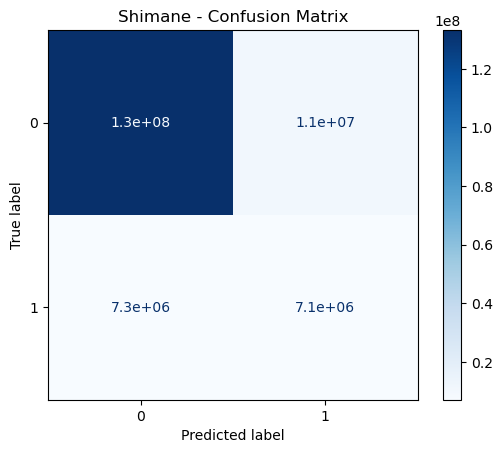

In [20]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# ============================================================
# 4. 面積評価（既存のHiroshimaテストと同じ指標）
# ============================================================
model.eval()

shimane_all_preds = []
shimane_all_targets = []
shimane_all_preds_imgs = []
shimane_all_targets_imgs = []

with torch.no_grad():
    for images, masks in tqdm(shimane_loader, desc="Evaluating on Shimane"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        shimane_all_preds.append(preds.cpu())
        shimane_all_targets.append(masks.cpu())
        shimane_all_preds_imgs.append(preds.cpu().numpy())
        shimane_all_targets_imgs.append(masks.cpu().numpy())

shimane_preds_flat = torch.cat(shimane_all_preds).numpy().flatten().astype(int)
shimane_targets_flat = torch.cat(shimane_all_targets).numpy().flatten().astype(int)

shimane_recall = recall_score(shimane_targets_flat, shimane_preds_flat, zero_division=0)
shimane_precision = precision_score(shimane_targets_flat, shimane_preds_flat, zero_division=0)
shimane_f1 = f1_score(shimane_targets_flat, shimane_preds_flat, zero_division=0)

print(f"[島根/面積評価] Recall: {shimane_recall:.4f}")
print(f"[島根/面積評価] Precision: {shimane_precision:.4f}")
print(f"[島根/面積評価] F1-score: {shimane_f1:.4f}")

shimane_cm = confusion_matrix(shimane_targets_flat, shimane_preds_flat)
print(shimane_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=shimane_cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Shimane - Confusion Matrix")
plt.show()

Generating Predictions: 100%|████████████████████████████████████████████████████████| 303/303 [00:11<00:00, 25.42it/s]


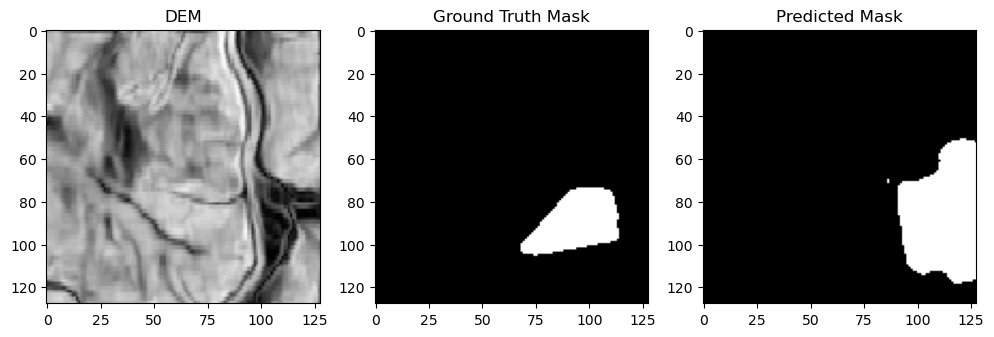

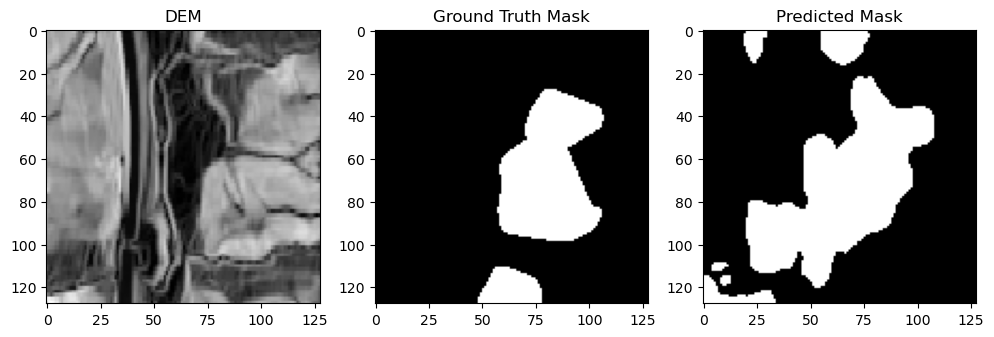

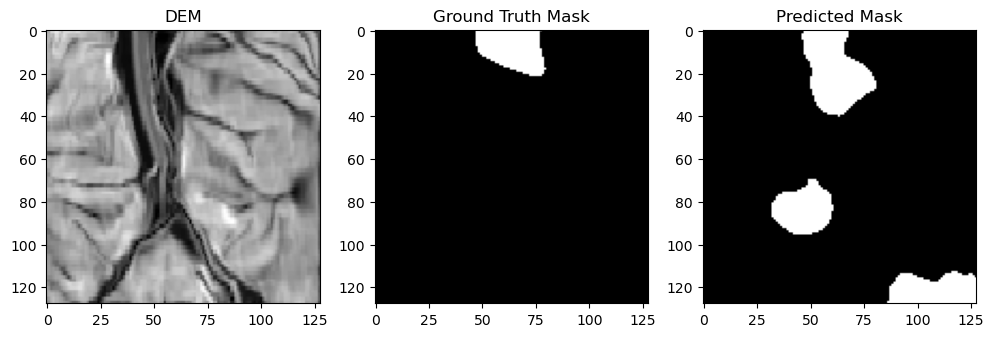

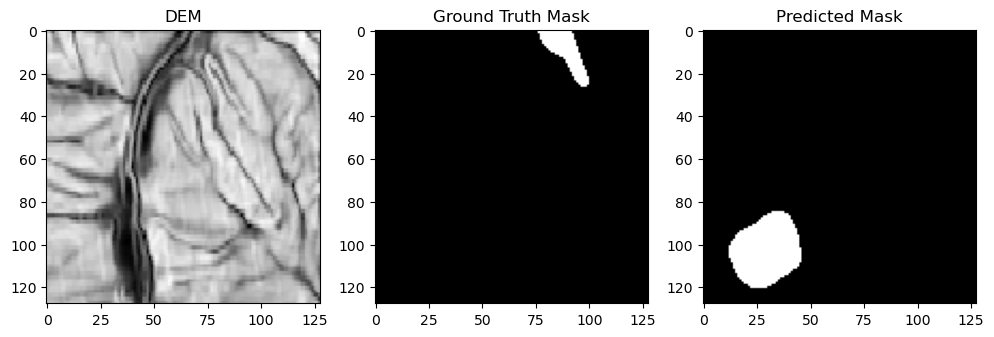

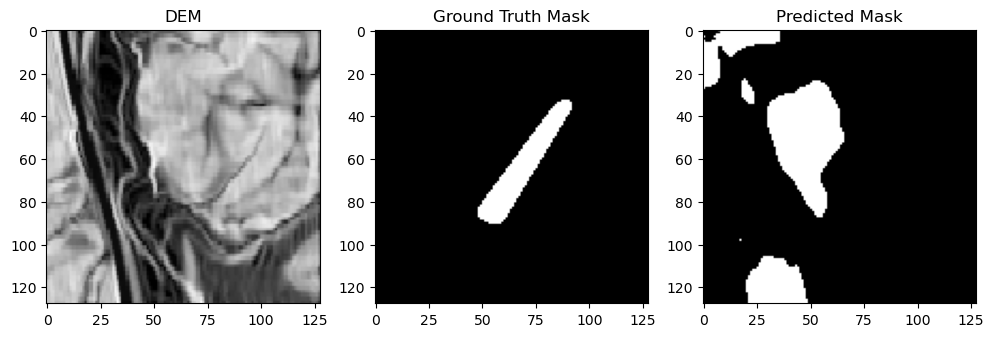

予測結果の画像枚数: 9679


In [21]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 设置模型为评估模式
model.eval()

# 用于存储测试集的预测结果
predictions = []
inputs = []
ground_truths = []

# 在测试集上生成预测结果
with torch.no_grad():
    for images, masks in tqdm(shimane_loader, desc="Generating Predictions"):
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        predictions.append(preds.cpu())
        inputs.append(images.cpu())
        ground_truths.append(masks.cpu())

# 将所有批次结果拼接
predictions = torch.cat(predictions).numpy()
inputs = torch.cat(inputs).numpy()
ground_truths = torch.cat(ground_truths).numpy()

# 显示和保存预测结果
n_display = 5  # 显示的图片数量
for i in range(n_display):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1,3,1)
    plt.title('DEM')
    plt.imshow(inputs[i][0], cmap='gray')

    # Ground Truth Mask
    plt.subplot(1, 3, 2)
    plt.title('Ground Truth Mask')
    plt.imshow(ground_truths[i][0], cmap='gray')  # 真值掩码假设为单通道

    # Predicted Mask
    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(predictions[i][0], cmap='gray')  # 预测掩码假设为单通道

    plt.show()

print(f"予測結果の画像枚数: {len(predictions)}")

In [ ]:
# ============================================================
# 5. 箇所数評価（連結成分ベース、閾値0.3と0.1の両方）
#    calc_ious / calc_eva は既存セルで定義済みのものをそのまま使う
# ============================================================
shimane_predictions = np.concatenate(shimane_all_preds_imgs, axis=0)
shimane_ground_truths = np.concatenate(shimane_all_targets_imgs, axis=0)

for threshold in [0.3, 0.1]:
    TP, FP, FN = 0, 0, 0
    for i in range(len(y_shimane)):
        bin_img = (np.array(shimane_predictions[i][0]) > 0.5).astype(np.uint8)
        pretval, plabels, pstats, pcentroids = cv2.connectedComponentsWithStats(bin_img)
        bin_img = (np.array(shimane_ground_truths[i][0]) > 0.5).astype(np.uint8)
        tretval, tlabels, tstats, tcentroids = cv2.connectedComponentsWithStats(bin_img)
        tp, fp, fn = calc_eva(tretval, pretval, tstats, pstats, threshold=threshold)
        TP += tp
        FP += fp
        FN += fn

    precision_loc = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall_loc = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1_loc = (2 * TP) / (2 * TP + FP + FN) if (TP + FP + FN) > 0 else 0.0

    print(f"[島根/箇所数評価 閾値{threshold}] TP:{TP} FP:{FP} FN:{FN}")
    print(f"[島根/箇所数評価 閾値{threshold}] Precision:{precision_loc:.4f} Recall:{recall_loc:.4f} F1:{f1_loc:.4f}")